In [1]:
import os
import sys
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# defining the project root to load the cleaned data
project_root = os.path.abspath('..')
processed_dir = os.path.join(project_root, 'data', 'processed')

In [2]:
# loading the strict, mathematically complete matrix from the previous step
data_path = os.path.join(processed_dir, 'world_bank_2019_cleaned.csv')
df = pd.read_csv(data_path)

print(f"I am analysing {len(df)} countries.")

I am analyzing 259 countries.


In [3]:
# define the target variable and take the natural logarithm
# This transforms exponential wealth growth into a linear scale
y = np.log(df['gdp_per_capita'])

# selective my independent variables (features)
# dropping the country identifiers and the original target variable
X = df.drop(columns=['country_code', 'country_name', 'gdp_per_capita'])

# In statsmodels, I must explicitly add a constant (the intercept, beta_0) to the model
X_with_constant = sm.add_constant(X)

# fitting the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X_with_constant).fit()

# printing the comprehensive statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         gdp_per_capita   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     105.3
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.22e-71
Time:                        16:49:27   Log-Likelihood:                -279.01
No. Observations:                 259   AIC:                             574.0
Df Residuals:                     251   BIC:                             602.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.1223      0.60

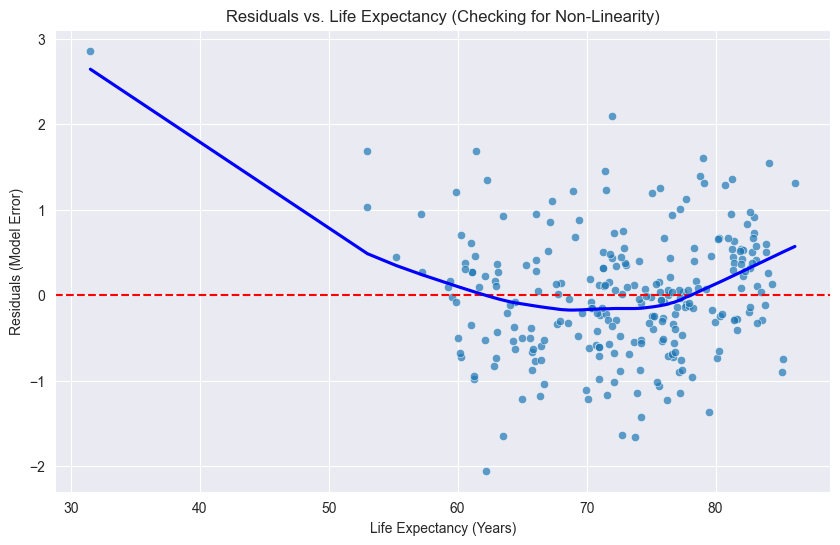

In [4]:
# I calculate the model's predictions and its residuals (actual - predicted)
predictions = model.predict(X_with_constant)
residuals = model.resid

# I create a figure to plot residuals against a specific variable: Life Expectancy
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['life_expectancy'], y=residuals, alpha=0.7)

# I add a horizontal line at zero to represent a "perfect" prediction
plt.axhline(y=0, color='r', linestyle='--')

# I add a smoothed trend line to easily spot any curves in the errors
sns.regplot(x=df['life_expectancy'], y=residuals, scatter=False, color='blue', lowess=True)

plt.title('Residuals vs. Life Expectancy (Checking for Non-Linearity)')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Residuals (Model Error)')
plt.show()